# Riesgo agroclimático por heladas en la región Puno

**Proyecto final — Visualización de Datos (SIS328)**  
Universidad Nacional del Altiplano · Escuela Profesional de Ingeniería de Sistemas  
Docente: **Ing. Edwin Edgar Mestas Yucra** · Semestre 2026-I · Ciclo X  

**Integrantes:** Aracayo Mamani, Jhon Marco · Canaza Paucara, Juan Diego · Luque Pacheco, Angie Tatiana  
**Fuente primaria:** ERA5-Land / ERA5 vía Open-Meteo · **Validación:** MERRA-2 / NASA POWER  
**Periodo:** 2015-01-01 a 2024-12-31 · **Ámbito:** trece provincias de Puno

Este cuaderno reproduce la carga original, el pipeline ETL, el análisis exploratorio, la inferencia estadística y las técnicas multivariantes utilizadas en el dashboard.

## 1. Objetivo y preguntas analíticas

El objetivo es transformar observaciones agrometeorológicas diarias en evidencia interpretable sobre la frecuencia, intensidad, distribución territorial y factores asociados a las heladas, declarando expresamente las limitaciones de resolución y cobertura. Las seis preguntas se importan de la configuración para evitar divergencias entre notebook, dashboard e informe.

In [1]:
from pathlib import Path
import json
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from scipy.cluster.hierarchy import dendrogram

from config.settings import (
    AUTHORS, COURSE, DATA_SOURCE, DATA_SOURCE_SECONDARY,
    MULTIVARIATE_FEATURES, PROJECT_PATHS, RANDOM_STATE,
    RESEARCH_QUESTIONS, STUDY_PERIOD,
)
from utils.metrics import (
    aggregate_annual, aggregate_by_province, aggregate_monthly,
    compare_sources, summary_table,
)
from utils.ml_models import (
    detect_anomalies, run_hierarchical_clustering, run_kmeans,
    run_pca, train_frost_classifier,
)
from utils.preprocessing import clean_dataset
from utils.stats_tools import (
    correlation_matrix, fit_linear_trend, mann_kendall_test,
    variance_inflation_factors,
)

%matplotlib inline
sns.set_theme(style='whitegrid', palette=['#DB8963', '#578BC5'])
plt.rcParams.update({'figure.figsize': (11, 5.5), 'figure.dpi': 110})
pd.set_option('display.max_columns', 60)
print(f'Raíz del proyecto: {ROOT}')
print(f'Semilla reproducible: {RANDOM_STATE}')
display(pd.DataFrame([
    {'Código': q.code, 'Pregunta': q.question, 'Página': q.page, 'Método': q.method}
    for q in RESEARCH_QUESTIONS
]))

Raíz del proyecto: D:\UNA-PUNO-JHON\10°SEMESTRE\visualisacionDatos\trabajo_final
Semilla reproducible: 42


,Código,Pregunta,Página,Método
0,P1,¿Cuál es la situación general del riesgo por h...,Vista general,"Indicadores clave, resumen ejecutivo y perfil ..."
1,P2,¿Cómo se distribuye la ocurrencia e intensidad...,Análisis descriptivo,"Gráfico de barras, histograma, diagrama de caj..."
2,P3,¿Cómo ha evolucionado la frecuencia e intensid...,Análisis descriptivo,"Serie temporal, regresión OLS, prueba de Mann-..."
3,P4,¿Qué provincias concentran el mayor y el menor...,Análisis descriptivo / Geográfico,"Ranking ordenado, mapa coroplético de puntos y..."
4,P5,"¿Qué relación existe entre la altitud, la hume...",Análisis multidimensional,"Dispersión con regresión, matriz de correlació..."
5,P6,¿Es posible identificar zonas agroclimáticas h...,Análisis multidimensional,"PCA, K-Means, clustering jerárquico, Isolation..."


## 2. Procedencia y decisión de resolución

ERA5-Land es la fuente primaria porque su malla aproximada de 9 km diferencia las capitales provinciales. En la malla MERRA-2 de aproximadamente 55 × 65 km varias capitales vecinas comparten celda y pueden recibir series idénticas, lo que volvería espurios los rankings o agrupamientos. MERRA-2 se integra sólo como validación independiente.

In [2]:
sources = pd.DataFrame([
    {
        'papel': 'Primaria', 'fuente': DATA_SOURCE.name,
        'organización': DATA_SOURCE.organization,
        'modelo': DATA_SOURCE.model, 'resolución': DATA_SOURCE.spatial_resolution,
        'periodo': STUDY_PERIOD.label, 'licencia': DATA_SOURCE.license_note,
    },
    {
        'papel': 'Validación', 'fuente': DATA_SOURCE_SECONDARY.name,
        'organización': DATA_SOURCE_SECONDARY.organization,
        'modelo': DATA_SOURCE_SECONDARY.model,
        'resolución': DATA_SOURCE_SECONDARY.spatial_resolution,
        'periodo': STUDY_PERIOD.label, 'licencia': DATA_SOURCE_SECONDARY.license_note,
    },
])
display(sources)
print('Cita primaria:', DATA_SOURCE.citation_apa)
print('Cita secundaria:', DATA_SOURCE_SECONDARY.citation_apa)

,papel,fuente,organización,modelo,resolución,periodo,licencia
0,Primaria,ERA5-Land / ERA5 (Copernicus Climate Change Se...,European Centre for Medium-Range Weather Forec...,Reanálisis ERA5-Land / ERA5 (configuración «er...,0.1° ≈ 9 km (ERA5-Land); 0.25° ≈ 28 km en las ...,2015–2024,Datos de Copernicus bajo licencia de uso abier...
1,Validación,NASA POWER — Prediction Of Worldwide Energy Re...,"NASA Langley Research Center (LaRC), Applied S...",Reanálisis MERRA-2 (Modern-Era Retrospective a...,0.5° × 0.625° (≈ 55 km × 65 km),2015–2024,Datos de dominio público. NASA POWER autoriza ...


Cita primaria: Muñoz-Sabater, J., Dutra, E., Agustí-Panareda, A., Albergel, C., Arduini, G., Balsamo, G., Boussetta, S., Choulga, M., Harrigan, S., Hersbach, H., Martens, B., Miralles, D. G., Piles, M., Rodríguez-Fernández, N. J., Zsoter, E., Buontempo, C., & Thépaut, J.-N. (2021). ERA5-Land: A state-of-the-art global reanalysis dataset for land applications. Earth System Science Data, 13(9), 4349–4383. https://doi.org/10.5194/essd-13-4349-2021
Cita secundaria: NASA Langley Research Center. (2025). NASA Prediction Of Worldwide Energy Resources (POWER) Project: Daily agroclimatology data (Version 2.9.6) [Conjunto de datos]. https://power.larc.nasa.gov/


## 3. Carga y auditoría del dataset original

Se inspecciona el artefacto consolidado sin aplicar transformaciones: dimensiones, tipos, muestra, estadísticos, ausencias, duplicados y unidades declaradas por el servicio.

In [3]:
raw = pd.read_csv(PROJECT_PATHS.original_dataset, low_memory=False)
validation_path = PROJECT_PATHS.data / 'datos_originales_validacion_merra2.csv'
validation = pd.read_csv(validation_path, low_memory=False)
units = json.loads((PROJECT_PATHS.raw_data / 'unidades_nativas_era5.json').read_text(encoding='utf-8'))

audit = pd.DataFrame({
    'métrica': ['filas', 'variables', 'provincias', 'ausentes', 'duplicados exactos'],
    'valor': [len(raw), raw.shape[1], raw['provincia'].nunique(),
              int(raw.isna().sum().sum()), int(raw.duplicated().sum())],
})
display(audit)
display(raw.head(5))
display(raw.describe(include='all').T.head(20))
display(pd.DataFrame({'columna': raw.columns, 'dtype': raw.dtypes.astype(str).values}))
print('Unidades nativas declaradas por ERA5/Open-Meteo:')
display(pd.Series(units, name='unidad').to_frame())

,métrica,valor
0,filas,47489
1,variables,32
2,provincias,13
3,ausentes,0
4,duplicados exactos,0


,provincia,capital,latitud_solicitada,longitud_solicitada,latitud_malla,longitud_malla,elevacion_malla_m,altitud_referencial_m,cuenca,zona_agroecologica,fuente,modelo,fecha_iso,temperature_2m_mean,temperature_2m_max,temperature_2m_min,dew_point_2m_mean,relative_humidity_2m_mean,precipitation_sum,rain_sum,snowfall_sum,precipitation_hours,shortwave_radiation_sum,wind_speed_10m_mean,wind_speed_10m_max,surface_pressure_mean,cloud_cover_mean,et0_fao_evapotranspiration,vapour_pressure_deficit_max,soil_temperature_0_to_7cm_mean,soil_moisture_0_to_7cm_mean,sunshine_duration
0,Puno,Puno,-15.8402,-70.0219,-15.799995,-70.0,3819.0,3827,Titicaca,Altiplano circunlacustre,ERA5-Land/ERA5 (Copernicus),era5_seamless,2015-01-01,10.1,14.7,5.3,3.5,64,0.9,0.9,0.0,3.0,25.79,8.8,12.3,652.9,99,4.34,0.80,14.9,0.273,40088.82
1,Puno,Puno,-15.8402,-70.0219,-15.799995,-70.0,3819.0,3827,Titicaca,Altiplano circunlacustre,ERA5-Land/ERA5 (Copernicus),era5_seamless,2015-01-02,8.3,11.7,6.0,5.1,81,10.7,10.7,0.0,19.0,13.91,8.3,14.1,652.8,99,2.14,0.45,13.0,0.326,15648.18
2,Puno,Puno,-15.8402,-70.0219,-15.799995,-70.0,3819.0,3827,Titicaca,Altiplano circunlacustre,ERA5-Land/ERA5 (Copernicus),era5_seamless,2015-01-03,8.3,11.7,5.4,3.5,72,6.6,6.6,0.0,16.0,20.58,8.5,14.3,653.8,99,3.30,0.53,13.2,0.327,27069.67
3,Puno,Puno,-15.8402,-70.0219,-15.799995,-70.0,3819.0,3827,Titicaca,Altiplano circunlacustre,ERA5-Land/ERA5 (Copernicus),era5_seamless,2015-01-04,7.7,10.3,5.9,4.9,83,7.4,7.4,0.0,19.0,14.82,7.1,11.8,654.1,99,2.24,0.31,12.6,0.351,15078.88
4,Puno,Puno,-15.8402,-70.0219,-15.799995,-70.0,3819.0,3827,Titicaca,Altiplano circunlacustre,ERA5-Land/ERA5 (Copernicus),era5_seamless,2015-01-05,9.0,13.4,6.1,5.7,80,6.9,6.9,0.0,20.0,26.15,7.0,12.9,654.0,80,3.93,0.46,14.4,0.347,44270.52


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
provincia,47489,13,Puno,3653,NaN,NaN,NaN,NaN,NaN,NaN,NaN
capital,47489,13,Puno,3653,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitud_solicitada,47489.0,NaN,NaN,NaN,-15.299869,0.658574,-16.2447,-15.8402,-15.3506,-14.9114,-14.0703
longitud_solicitada,47489.0,NaN,NaN,NaN,-69.8876,0.430866,-70.5897,-70.1969,-69.8722,-69.4906,-69.0906
latitud_malla,47489.0,NaN,NaN,NaN,-15.292307,0.662707,-16.199997,-15.799995,-15.400002,-14.900002,-14.099998
longitud_malla,47489.0,NaN,NaN,NaN,-69.892307,0.428708,-70.6,-70.2,-69.9,-69.5,-69.1
elevacion_malla_m,47489.0,NaN,NaN,NaN,3783.307692,449.782866,2294.0,3828.0,3861.0,3872.0,4321.0
altitud_referencial_m,47489.0,NaN,NaN,NaN,3767.846154,477.185017,2170.0,3841.0,3860.0,3890.0,4315.0
cuenca,47489,2,Titicaca,40183,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zona_agroecologica,47489,4,Altiplano circunlacustre,21918,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,columna,dtype
0,provincia,object
1,capital,object
2,latitud_solicitada,float64
3,longitud_solicitada,float64
4,latitud_malla,float64
5,longitud_malla,float64
6,elevacion_malla_m,float64
7,altitud_referencial_m,int64
8,cuenca,object
9,zona_agroecologica,object


Unidades nativas declaradas por ERA5/Open-Meteo:


,unidad
time,iso8601
temperature_2m_mean,°C
temperature_2m_max,°C
temperature_2m_min,°C
dew_point_2m_mean,°C
relative_humidity_2m_mean,%
precipitation_sum,mm
rain_sum,mm
snowfall_sum,cm
precipitation_hours,h


**Lectura.** El original contiene 47 489 observaciones (3 653 días × 13 provincias) y 32 variables. La fecha todavía es texto y las velocidades, presión y duración solar conservan unidades nativas; por ello el archivo requiere transformación aun cuando no presenta valores ausentes ni duplicados exactos.

## 4. Pipeline de limpieza, integración y transformación

La misma función utilizada para construir el dataset del dashboard se ejecuta desde cero. Su bitácora registra cada decisión y evita que la limpieza sea una caja negra.

In [4]:
clean, cleaning_report = clean_dataset(raw, validation)
display(pd.DataFrame({
    'paso': range(1, len(cleaning_report.steps) + 1),
    'descripción': cleaning_report.steps,
}))
display(pd.DataFrame([{
    'entrada': f'{cleaning_report.rows_input:,} × {cleaning_report.columns_input}',
    'salida': f'{cleaning_report.rows_output:,} × {cleaning_report.columns_output}',
    'centinelas': cleaning_report.total_sentinels,
    'fuera_rango': cleaning_report.total_out_of_range,
    'imputados': cleaning_report.total_imputed,
    'duplicados_eliminados': cleaning_report.duplicates_removed,
    'precipitaciones_marcadas': cleaning_report.suspicious_precipitation,
}]))

,paso,descripción
0,1,"Inicio del pipeline: 47,489 filas × 32 columna..."
1,2,Normalización del esquema: 19 variables nativa...
2,3,La fecha llegaba como cadena de texto ISO; se ...
3,4,Homogeneización de unidades en 4 variables: ve...
4,5,No se hallaron valores centinela (-999.0); el ...
5,6,Validación de rangos físicos sobre 19 variable...
6,7,Verificación de coherencia térmica (mínima ≤ m...
7,8,Control de calidad de la precipitación: 1 acum...
8,9,Control de unicidad sobre la clave natural (pr...
9,10,"Reindexado al calendario diario completo (3,65..."


,entrada,salida,centinelas,fuera_rango,imputados,duplicados_eliminados,precipitaciones_marcadas
0,"47,489 × 32","47,489 × 52",0,0,0,0,1


**Interpretación.** El pipeline conserva las 47 489 filas, genera 52 variables analíticas, integra 47 489 pares MERRA-2 y no necesita imputar observaciones. Un acumulado de precipitación superior a 100 mm queda marcado, no borrado. La radiación se valida como MJ/m²/día con límite superior de 45, evitando confundirla con kWh/m²/día.

## 5. Verificación de los requisitos oficiales del dataset

In [5]:
checks = pd.DataFrame([
    ('Al menos 500 registros', len(clean) >= 500, f'{len(clean):,}'),
    ('Al menos seis variables', clean.shape[1] >= 6, str(clean.shape[1])),
    ('Variables numéricas y categóricas',
     len(clean.select_dtypes(include='number').columns) > 0 and
     len(clean.select_dtypes(include=['object', 'category', 'bool']).columns) > 0,
     'ambos tipos presentes'),
    ('Variable temporal', pd.api.types.is_datetime64_any_dtype(clean['fecha']), 'fecha diaria'),
    ('Variables geográficas', {'latitud', 'longitud', 'provincia'}.issubset(clean.columns),
     'latitud, longitud y provincia'),
    ('Fuente verificable y citada', bool(DATA_SOURCE.citation_apa), DATA_SOURCE.organization),
    ('Requiere transformación/integración', len(cleaning_report.derived_variables) > 0,
     f'{len(cleaning_report.derived_variables)} variables derivadas'),
    ('Sin información personal sensible', True, 'variables ambientales por punto de malla'),
    ('Sin ausentes residuales', clean.isna().sum().sum() == 0,
     f'{int(clean.isna().sum().sum())} celdas'),
    ('Clave provincia-fecha única', not clean.duplicated(['provincia', 'fecha']).any(),
     f"{int(clean.duplicated(['provincia', 'fecha']).sum())} duplicados"),
], columns=['requisito', 'cumple', 'evidencia'])
display(checks)
assert checks['cumple'].all(), 'Existe al menos un requisito incumplido'

,requisito,cumple,evidencia
0,Al menos 500 registros,True,"47,489"
1,Al menos seis variables,True,52
2,Variables numéricas y categóricas,True,ambos tipos presentes
3,Variable temporal,True,fecha diaria
4,Variables geográficas,True,"latitud, longitud y provincia"
5,Fuente verificable y citada,True,European Centre for Medium-Range Weather Forec...
6,Requiere transformación/integración,True,23 variables derivadas
7,Sin información personal sensible,True,variables ambientales por punto de malla
8,Sin ausentes residuales,True,0 celdas
9,Clave provincia-fecha única,True,0 duplicados


## 6. Análisis exploratorio: distribución e intensidad

Se describen variables térmicas e hídricas y se comparan los umbrales meteorológico (0 °C) y agronómico (3 °C). El boxplot muestra simultáneamente posición, dispersión y extremos por provincia.

,Variable,Unidad,n,Media,Mediana,Desv. típica,Mínimo,P5,Q1,Q3,P95,Máximo,Asimetría,Curtosis
0,temperatura_minima,°C,47489,3.79,4.00,3.49,-9.10,-2.00,1.30,6.10,9.60,14.50,0.05,-0.11
1,temperatura_media,°C,47489,8.99,9.00,2.34,-1.70,5.20,7.60,10.20,13.60,17.30,0.29,0.99
2,temperatura_maxima,°C,47489,14.43,14.30,2.56,2.50,10.40,12.80,16.00,18.90,27.30,-0.05,0.56
3,oscilacion_termica,°C,47489,10.63,10.00,3.83,0.90,5.20,7.70,13.40,17.60,23.80,0.46,-0.52
4,precipitacion,mm,47489,3.62,1.30,5.33,0.00,0.00,0.00,5.60,13.50,103.90,3.09,19.33
5,humedad_relativa,%,47489,65.83,69.00,16.93,7.00,34.00,54.00,79.00,90.00,100.00,-0.59,-0.23
6,radiacion_solar,MJ/m²,47489,22.76,22.48,4.50,3.28,15.28,20.11,25.72,30.47,35.15,-0.11,0.31
7,velocidad_viento,m/s,47489,1.89,1.83,0.61,0.47,1.03,1.42,2.28,2.97,7.06,0.69,0.83
8,indice_riesgo_helada,0–100,47489,31.71,26.44,16.56,8.22,13.47,17.65,43.55,64.03,90.48,0.81,-0.33


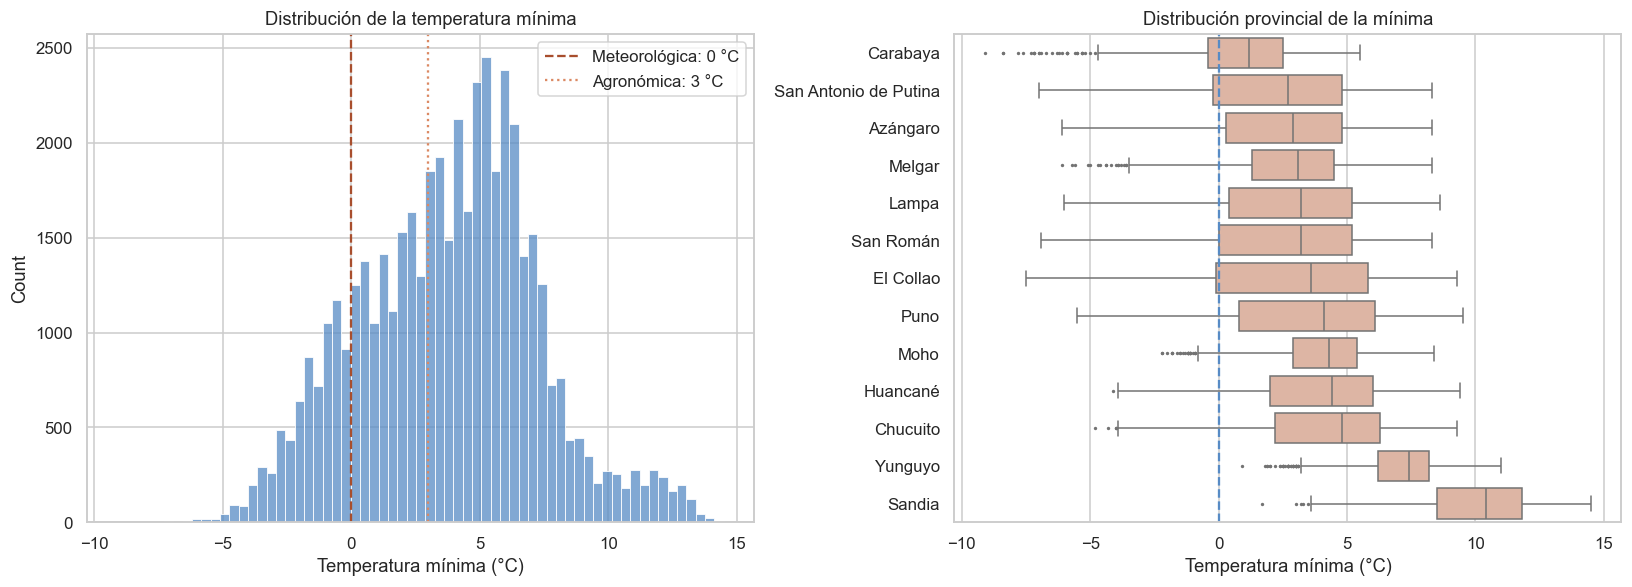

,valor
helada_meteorologica_%,16.046
helada_agronomica_%,39.750
factor_umbral,2.477


In [6]:
eda_variables = [
    'temperatura_minima', 'temperatura_media', 'temperatura_maxima',
    'oscilacion_termica', 'precipitacion', 'humedad_relativa',
    'radiacion_solar', 'velocidad_viento', 'indice_riesgo_helada',
]
display(summary_table(clean, eda_variables))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
sns.histplot(clean, x='temperatura_minima', bins=65, color='#578BC5', ax=axes[0])
axes[0].axvline(0, color='#A84E2D', linestyle='--', label='Meteorológica: 0 °C')
axes[0].axvline(3, color='#DB8963', linestyle=':', label='Agronómica: 3 °C')
axes[0].set(title='Distribución de la temperatura mínima', xlabel='Temperatura mínima (°C)')
axes[0].legend()
order = clean.groupby('provincia', observed=True)['temperatura_minima'].median().sort_values().index
sns.boxplot(data=clean, y='provincia', x='temperatura_minima', order=order,
            color='#E7B19A', fliersize=1.2, ax=axes[1])
axes[1].axvline(0, color='#578BC5', linestyle='--')
axes[1].set(title='Distribución provincial de la mínima', xlabel='Temperatura mínima (°C)', ylabel='')
plt.tight_layout()
plt.show()
rates = pd.Series({
    'helada_meteorologica_%': clean['helada'].mean() * 100,
    'helada_agronomica_%': clean['helada_agronomica'].mean() * 100,
    'factor_umbral': clean['helada_agronomica'].mean() / clean['helada'].mean(),
})
display(rates.to_frame('valor').round(3))

**Hallazgo.** El 16,05 % de las observaciones provincia-día alcanza el umbral meteorológico, frente al 39,75 % bajo el umbral agronómico. Planificar sólo con 0 °C subestima la ventana de exposición potencial del cultivo por un factor cercano a 2,48.

## 7. Ciclo anual, evolución temporal y tendencia

Los conteos anuales se normalizan por el número de provincias presentes. OLS evalúa una pendiente lineal; Mann-Kendall contrasta una tendencia monótona sin asumir normalidad y Sen aporta una pendiente robusta.

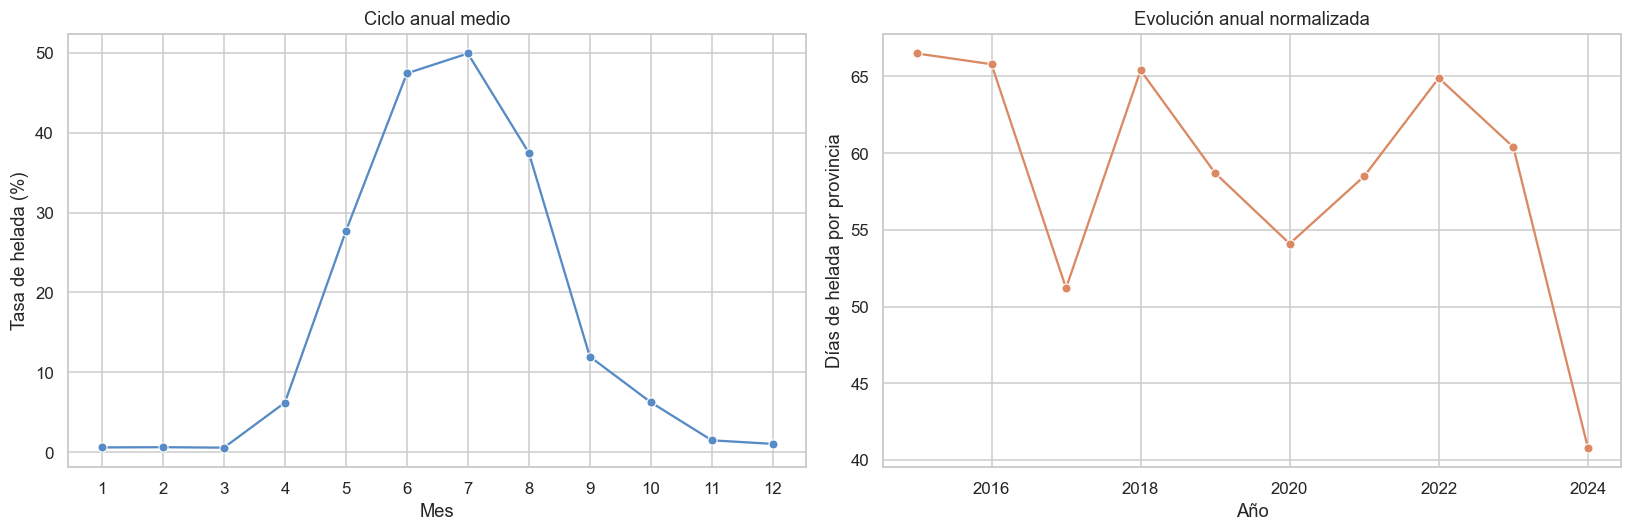

,serie,método,pendiente,p,dirección
0,Heladas por provincia,OLS,-1.3691,0.1324,estable
1,Heladas por provincia,Mann-Kendall/Sen,-1.0000,0.1074,sin tendencia
2,Temperatura mínima media,OLS,0.0581,0.1199,estable
3,Temperatura mínima media,Mann-Kendall/Sen,0.0467,0.1780,sin tendencia


In [7]:
monthly = aggregate_monthly(clean)
annual = aggregate_annual(clean)
province = aggregate_by_province(clean)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(data=monthly, x='mes', y='tasa_helada', marker='o',
             color='#578BC5', ax=axes[0])
axes[0].set(title='Ciclo anual medio', xlabel='Mes', ylabel='Tasa de helada (%)', xticks=range(1, 13))
sns.lineplot(data=annual, x='anio', y='heladas_por_provincia', marker='o',
             color='#DB8963', ax=axes[1])
axes[1].set(title='Evolución anual normalizada', xlabel='Año',
            ylabel='Días de helada por provincia')
plt.tight_layout()
plt.show()

trend_frost_ols = fit_linear_trend(annual['anio'], annual['heladas_por_provincia'])
trend_frost_mk = mann_kendall_test(annual['heladas_por_provincia'])
trend_tmin_ols = fit_linear_trend(annual['anio'], annual['tmin_media'])
trend_tmin_mk = mann_kendall_test(annual['tmin_media'])
display(pd.DataFrame([
    {'serie': 'Heladas por provincia', 'método': 'OLS', 'pendiente': trend_frost_ols.slope,
     'p': trend_frost_ols.p_value, 'dirección': trend_frost_ols.direction},
    {'serie': 'Heladas por provincia', 'método': 'Mann-Kendall/Sen',
     'pendiente': trend_frost_mk.sen_slope, 'p': trend_frost_mk.p_value,
     'dirección': trend_frost_mk.trend},
    {'serie': 'Temperatura mínima media', 'método': 'OLS', 'pendiente': trend_tmin_ols.slope,
     'p': trend_tmin_ols.p_value, 'dirección': trend_tmin_ols.direction},
    {'serie': 'Temperatura mínima media', 'método': 'Mann-Kendall/Sen',
     'pendiente': trend_tmin_mk.sen_slope, 'p': trend_tmin_mk.p_value,
     'dirección': trend_tmin_mk.trend},
]).round(4))

**Interpretación.** OLS estima −1,37 días de helada por provincia y año (`p = 0,132`) y Mann-Kendall no rechaza la ausencia de tendencia (`p = 0,107`). La mínima media tampoco presenta tendencia significativa. Diez años caracterizan variabilidad interanual, pero son insuficientes para atribuir cambio climático.

## 8. Correlaciones, multicolinealidad y gradiente altitudinal

La matriz identifica asociaciones lineales; el VIF evita interpretar como independientes variables que comparten información. El gradiente se estima sobre los trece perfiles provinciales, no sobre 47 489 réplicas diarias de la misma altitud.

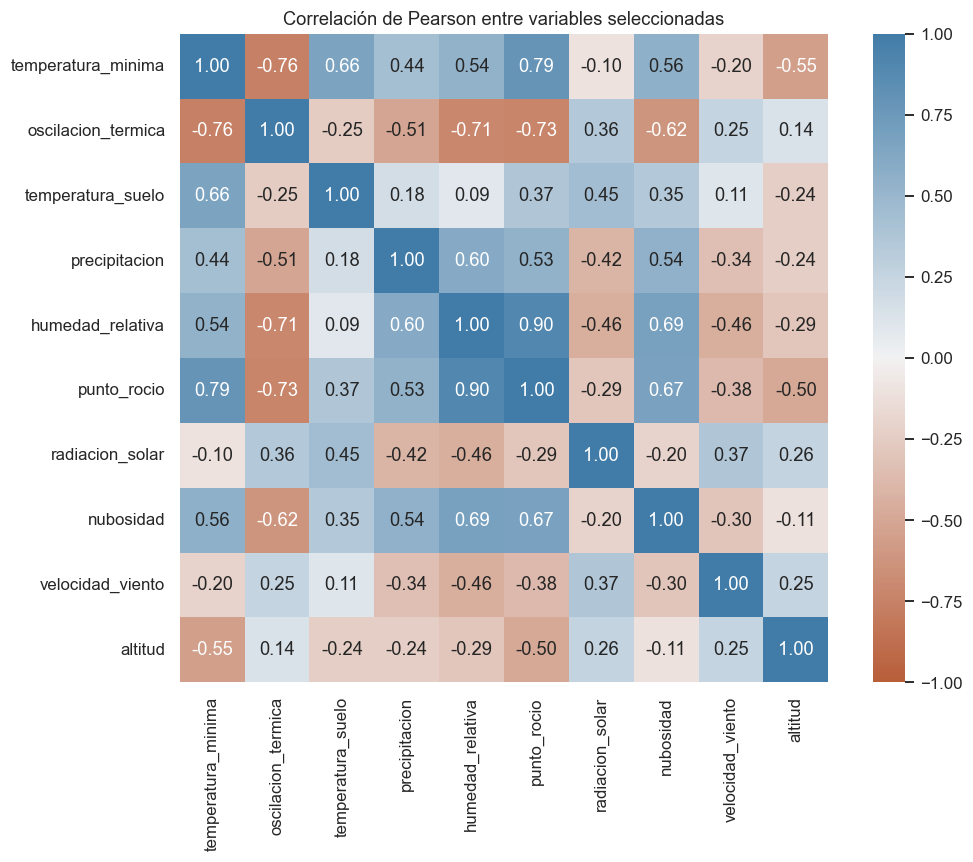

,variable,VIF,lectura
0,evapotranspiracion,61.55,multicolinealidad severa
1,punto_rocio,37.34,multicolinealidad severa
2,radiacion_solar,36.19,multicolinealidad severa
3,humedad_relativa,34.79,multicolinealidad severa
4,temperatura_minima,33.56,multicolinealidad severa
5,oscilacion_termica,19.19,multicolinealidad severa
6,temperatura_suelo,7.50,multicolinealidad moderada
7,humedad_suelo,5.22,multicolinealidad moderada
8,altitud,4.50,aceptable
9,nubosidad,2.92,aceptable


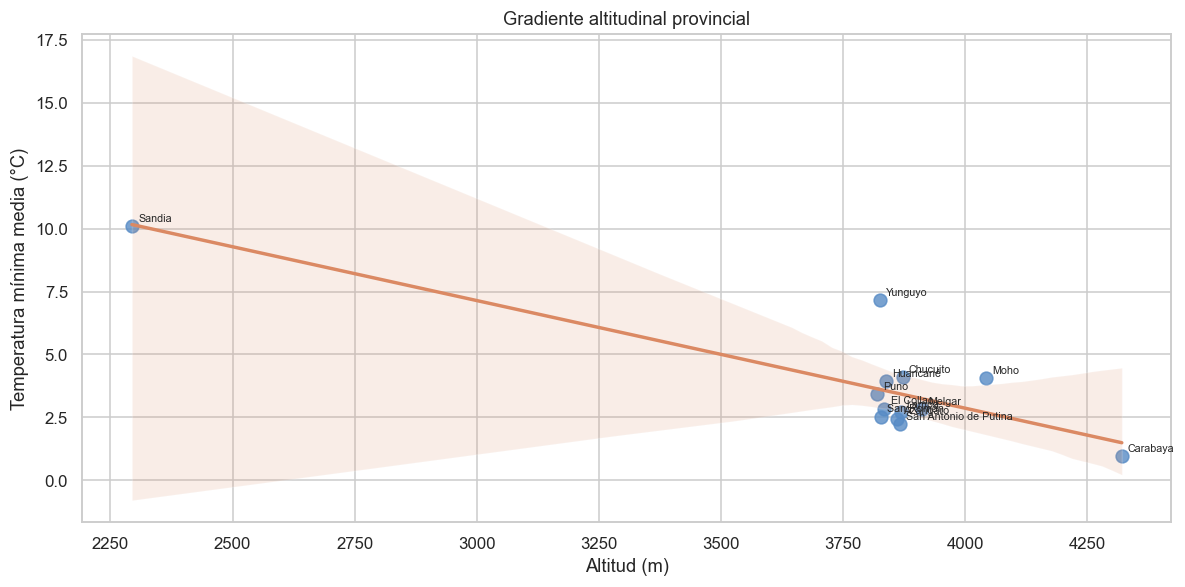

,valor
pendiente_°C_por_100m,-0.4276
R2,0.7049
p,0.0003
IC95_inferior,-0.6111
IC95_superior,-0.2440


In [8]:
corr_variables = [
    'temperatura_minima', 'oscilacion_termica', 'temperatura_suelo',
    'precipitacion', 'humedad_relativa', 'punto_rocio',
    'radiacion_solar', 'nubosidad', 'velocidad_viento', 'altitud',
]
corr = correlation_matrix(clean, corr_variables)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap=sns.diverging_palette(25, 240, as_cmap=True),
            center=0, vmin=-1, vmax=1, annot=True, fmt='.2f', square=True)
plt.title('Correlación de Pearson entre variables seleccionadas')
plt.tight_layout()
plt.show()
display(variance_inflation_factors(clean, list(MULTIVARIATE_FEATURES)))

altitude_trend = fit_linear_trend(province['altitud'] / 100, province['tmin_media'])
ax = sns.regplot(data=province, x='altitud', y='tmin_media',
                 scatter_kws={'s': 70, 'color': '#578BC5'},
                 line_kws={'color': '#DB8963'})
for _, row in province.iterrows():
    ax.annotate(row['provincia'], (row['altitud'], row['tmin_media']),
                xytext=(4, 3), textcoords='offset points', fontsize=7)
ax.set(title='Gradiente altitudinal provincial', xlabel='Altitud (m)',
       ylabel='Temperatura mínima media (°C)')
plt.tight_layout()
plt.show()
display(pd.Series({
    'pendiente_°C_por_100m': altitude_trend.slope,
    'R2': altitude_trend.r_squared, 'p': altitude_trend.p_value,
    'IC95_inferior': altitude_trend.confidence_interval[0],
    'IC95_superior': altitude_trend.confidence_interval[1],
}).to_frame('valor').round(4))

**Hallazgo.** El gradiente es −0,428 °C por 100 m (`R² = 0,705`, `p = 0,00033`), pero no explica por sí solo la incidencia. Yunguyo y San Román se ubican alrededor de 3 825 m y acumulan 0 frente a 930 días; la inercia térmica lacustre y otros controles locales impiden una zonificación basada únicamente en altitud.

## 9. PCA y agrupamientos

Las doce variables se estandarizan antes del PCA y K-Means. El número de grupos se elige por silueta entre `k = 2…4`; el agrupamiento jerárquico de Ward trabaja sobre trece perfiles provinciales para conservar una unidad territorial interpretable.

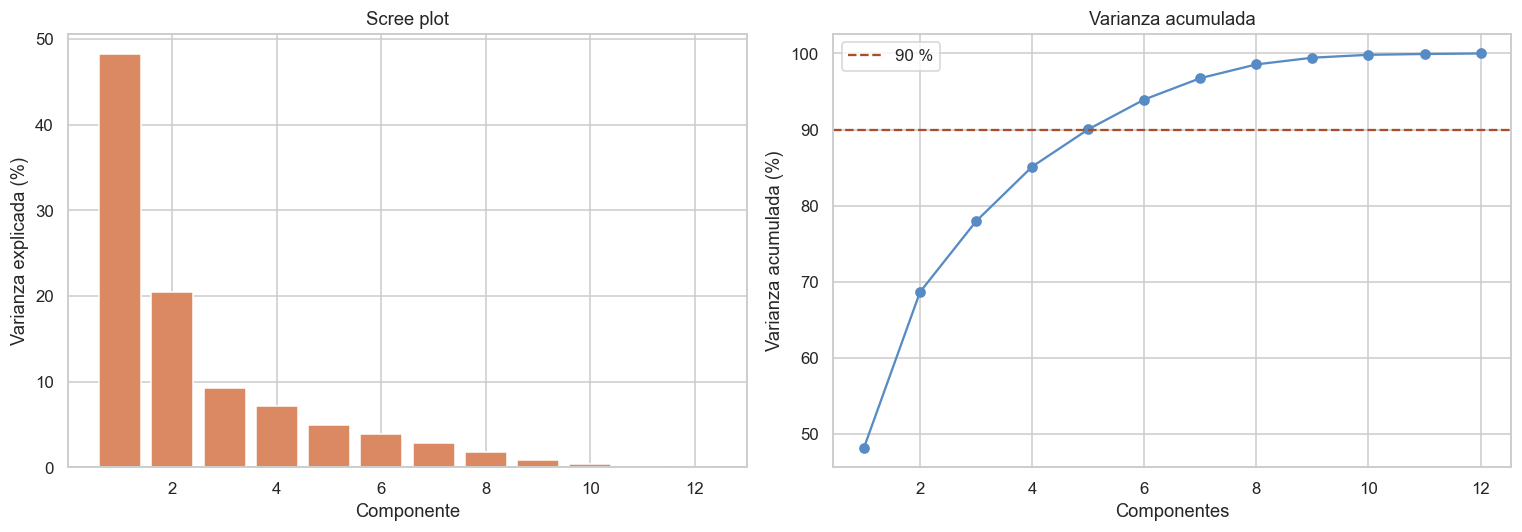

,CP1,CP2,CP3
temperatura_minima,0.308,0.340,-0.234
oscilacion_termica,-0.341,-0.071,-0.174
temperatura_suelo,0.091,0.579,-0.077
precipitacion,0.297,-0.029,0.085
humedad_relativa,0.382,-0.054,0.143
punto_rocio,0.380,0.146,-0.066
radiacion_solar,-0.219,0.469,0.224
nubosidad,0.315,0.145,0.348
velocidad_viento,-0.220,0.179,0.062
evapotranspiracion,-0.239,0.487,0.098


CP1 (48,2 % de la varianza): aumenta con Humedad relativa, Punto de rocío y disminuye con Oscilación térmica.
CP2 (20,5 % de la varianza): aumenta con Temperatura del suelo, Evapotranspiración de referencia, Radiación solar.
Componentes necesarias para 90 %: 5


In [9]:
pca = run_pca(clean, list(MULTIVARIATE_FEATURES),
              n_components=len(MULTIVARIATE_FEATURES))
assert pca is not None
components = np.arange(1, len(pca.explained_variance) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(components, pca.explained_variance * 100, color='#DB8963')
axes[0].set(title='Scree plot', xlabel='Componente', ylabel='Varianza explicada (%)')
axes[1].plot(components, pca.cumulative_variance * 100, marker='o', color='#578BC5')
axes[1].axhline(90, color='#A84E2D', linestyle='--', label='90 %')
axes[1].set(title='Varianza acumulada', xlabel='Componentes', ylabel='Varianza acumulada (%)')
axes[1].legend()
plt.tight_layout()
plt.show()
display(pca.loadings.iloc[:, :3].round(3))
print(pca.interpret_component(0))
print(pca.interpret_component(1))
print(f'Componentes necesarias para 90 %: {pca.n_components_90}')

**Interpretación del PCA.** CP1 explica 48,2 % y contrapone humedad/punto de rocío con oscilación térmica; CP2 explica 20,5 % y está asociado a temperatura de suelo, evapotranspiración y radiación. Se necesitan cinco componentes para superar 90 %, señal de que el régimen no puede reducirse responsablemente a un único eje.

C:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


,k,inercia,silueta
0,2,40273.055,0.293
1,3,33399.720,0.306
2,4,27230.994,0.298


,grupo,n_dias,tmin_media,tmax_media,oscilacion_media,precipitacion_media,humedad_media,nubosidad_media,radiacion_media,viento_medio,altitud_media,tasa_helada,riesgo_medio,temporada_dominante,provincias_frecuentes,etiqueta
0,0,19896,1.43,15.280000,13.85,0.32,50.05,35.60,24.320000,2.20,3880.620117,34.4,47.439999,Seca,"El Collao, San Román, Puno",Helada frecuente · seco · amplitud moderada
1,1,23939,4.79,13.140000,8.35,5.60,75.51,85.04,22.299999,1.75,3929.689941,3.2,20.889999,Lluviosa,"Carabaya, Yunguyo, Chucuito",Libre de helada · húmedo · amplitud moderada
2,2,3654,10.10,18.190001,8.09,8.63,88.34,81.83,17.260000,1.14,2294.429932,0.0,17.000000,Seca,"Sandia, San Antonio de Putina, Azángaro",Libre de helada · húmedo · amplitud moderada


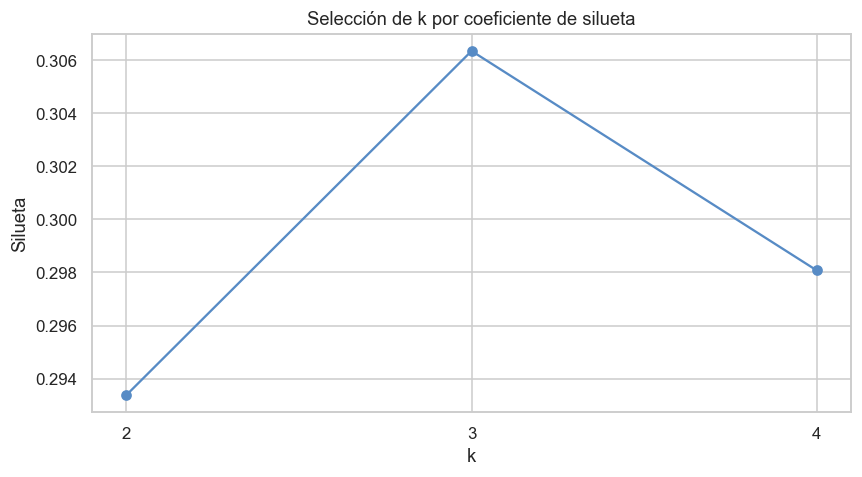

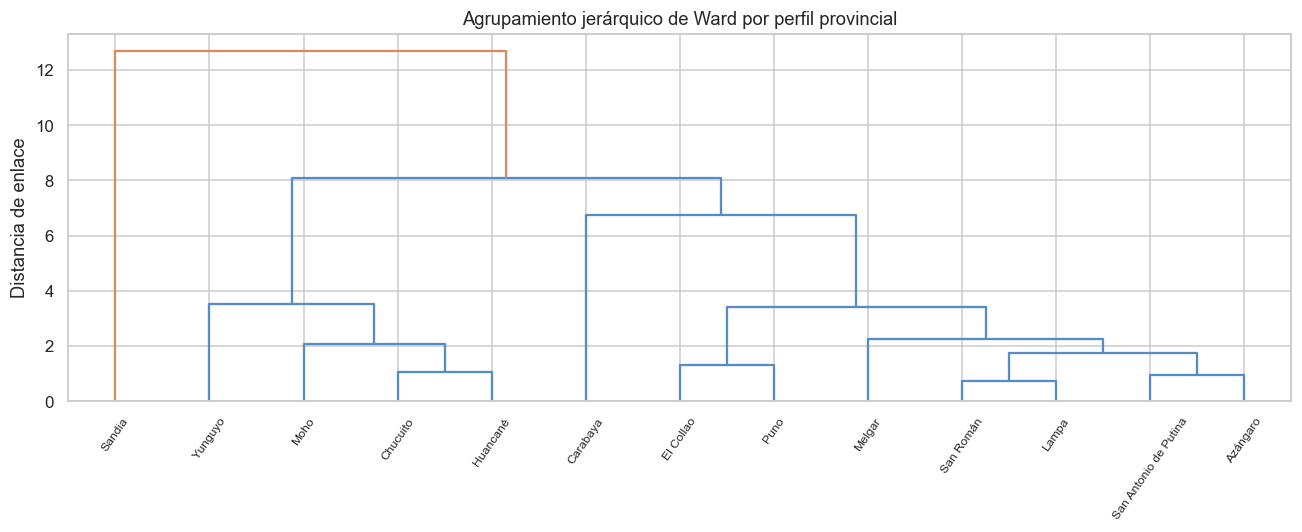

,provincia,grupo
8,Chucuito,0
9,Huancané,0
10,Moho,0
12,Yunguyo,0
11,Sandia,1
4,Azángaro,2
2,El Collao,2
5,Lampa,2
7,Melgar,2
6,Puno,2


In [10]:
clusters = run_kmeans(clean, list(MULTIVARIATE_FEATURES), max_clusters=4)
assert clusters is not None
display(clusters.diagnostics.round(3))
display(clusters.profile)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(clusters.diagnostics['k'], clusters.diagnostics['silueta'],
        marker='o', color='#578BC5')
ax.set(title='Selección de k por coeficiente de silueta', xlabel='k',
       ylabel='Silueta', xticks=clusters.diagnostics['k'])
plt.tight_layout()
plt.show()

hierarchical_features = [
    'heladas_por_anio', 'tasa_helada', 'tmin_media', 'tmin_absoluta',
    'oscilacion_media', 'precipitacion_anual', 'humedad_media',
    'nubosidad_media', 'radiacion_media', 'viento_medio', 'riesgo_medio', 'altitud',
]
hierarchical = run_hierarchical_clustering(province, hierarchical_features, n_clusters=4)
assert hierarchical is not None
plt.figure(figsize=(12, 5))
dendrogram(hierarchical.linkage_matrix, labels=hierarchical.province_names,
           leaf_rotation=55, leaf_font_size=8, color_threshold=None)
plt.title('Agrupamiento jerárquico de Ward por perfil provincial')
plt.ylabel('Distancia de enlace')
plt.tight_layout()
plt.show()
display(pd.DataFrame({'provincia': hierarchical.province_names,
                      'grupo': hierarchical.labels}).sort_values(['grupo', 'provincia']))

**Interpretación del agrupamiento.** K-Means selecciona `k = 3`, pero la silueta de 0,306 describe una estructura débil: los grupos son perfiles exploratorios, no zonas con fronteras naturales rígidas. Ward ofrece una lectura complementaria a escala provincial y evita confundir la repetición diaria con evidencia territorial independiente.

## 10. Anomalías y modelo explicativo de helada

Isolation Forest marca combinaciones multivariantes infrecuentes sin eliminarlas. El Random Forest utiliza una separación temporal y excluye temperatura mínima, déficit térmico e índice de riesgo porque contienen o derivan directamente la definición del objetivo. La importancia por permutación se interpreta como asociación predictiva, no causalidad.

Observaciones marcadas: 475 (1.0%)


,fecha,provincia,temperatura_minima,temperatura_maxima,oscilacion_termica,precipitacion,humedad_relativa,nubosidad,radiacion_solar,velocidad_viento,indice_riesgo_helada,intensidad_helada,precipitacion_sospechosa,puntuacion_anomalia
0,2024-03-22,Sandia,13.7,16.700001,3.0,70.500000,96,100,3.91,0.750000,10.40,Sin helada,False,-0.6828
1,2024-01-25,Sandia,13.3,17.500000,4.2,46.500000,100,100,6.40,0.972222,8.78,Sin helada,False,-0.6665
2,2020-02-01,Sandia,13.3,16.900000,3.6,48.500000,96,97,5.11,0.694444,11.22,Sin helada,False,-0.6656
3,2015-11-30,Sandia,13.0,14.700000,1.7,38.200001,98,100,5.11,0.666667,9.83,Sin helada,False,-0.6634
4,2019-11-28,Sandia,13.0,16.900000,3.9,56.799999,98,100,8.45,0.833333,9.63,Sin helada,False,-0.6621
5,2023-03-09,Sandia,13.3,16.500000,3.2,49.099998,97,100,5.33,1.000000,9.75,Sin helada,False,-0.6606
6,2021-02-10,Sandia,13.3,16.000000,2.7,60.000000,99,100,7.29,1.138889,8.91,Sin helada,False,-0.6598
7,2024-12-07,Sandia,13.7,17.900000,4.2,38.599998,97,100,9.82,0.694444,10.13,Sin helada,False,-0.6592
8,2024-02-12,Sandia,14.3,16.400000,2.1,25.200001,98,100,7.60,0.777778,9.69,Sin helada,False,-0.6588
9,2018-11-24,Sandia,12.7,16.799999,4.1,56.900002,96,100,5.24,0.777778,10.36,Sin helada,False,-0.6581


,valor
AUC_ROC,0.9903
precisión_media_PR,0.9482
exactitud,0.9523
sensibilidad,0.9447
precisión_clase_helada,0.7816
prevalencia,0.1605
n_entrenamiento,35616.0000
n_prueba,11873.0000


,pred_sin_helada,pred_helada
real_sin_helada,9632,468
real_helada,98,1675


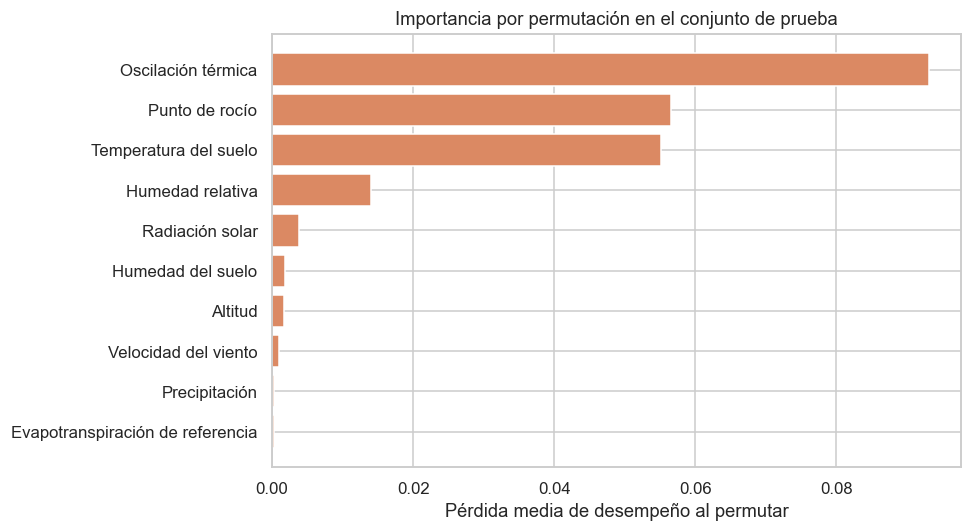

In [11]:
anomalies = detect_anomalies(clean, list(MULTIVARIATE_FEATURES),
                             contamination=0.01, top=15)
assert anomalies is not None
print(f'Observaciones marcadas: {anomalies.n_anomalies} ({anomalies.contamination:.1%})')
display(anomalies.extremes)

classifier = train_frost_classifier(clean, list(MULTIVARIATE_FEATURES))
assert classifier is not None
display(pd.Series({
    'AUC_ROC': classifier.roc_auc,
    'precisión_media_PR': classifier.average_precision,
    'exactitud': classifier.accuracy,
    'sensibilidad': classifier.recall,
    'precisión_clase_helada': classifier.precision,
    'prevalencia': classifier.positive_rate,
    'n_entrenamiento': classifier.n_train,
    'n_prueba': classifier.n_test,
}).to_frame('valor').round(4))
display(pd.DataFrame(classifier.confusion,
                     index=['real_sin_helada', 'real_helada'],
                     columns=['pred_sin_helada', 'pred_helada']))
top_importance = classifier.importances.head(10).sort_values('importancia')
plt.figure(figsize=(9, 5))
plt.barh(top_importance['etiqueta'], top_importance['importancia'], color='#DB8963')
plt.title('Importancia por permutación en el conjunto de prueba')
plt.xlabel('Pérdida media de desempeño al permutar')
plt.tight_layout()
plt.show()

**Lectura.** Se marcan 475 observaciones (1 %) para revisión. El clasificador obtiene AUC ROC 0,990, sensibilidad 0,945 y precisión 0,782; la oscilación térmica, el punto de rocío y la temperatura del suelo encabezan las importancias. Estas métricas no convierten el modelo en un sistema de alerta operacional: faltan validación con estaciones y evaluación prospectiva.

## 11. Validación cruzada entre fuentes

,valor
n_pares,47489.0000
correlacion,0.6106
sesgo_medio,1.2880
error_absoluto_medio,2.5430
raiz_error_cuadratico_medio,3.2330
concordancia_helada,83.0600


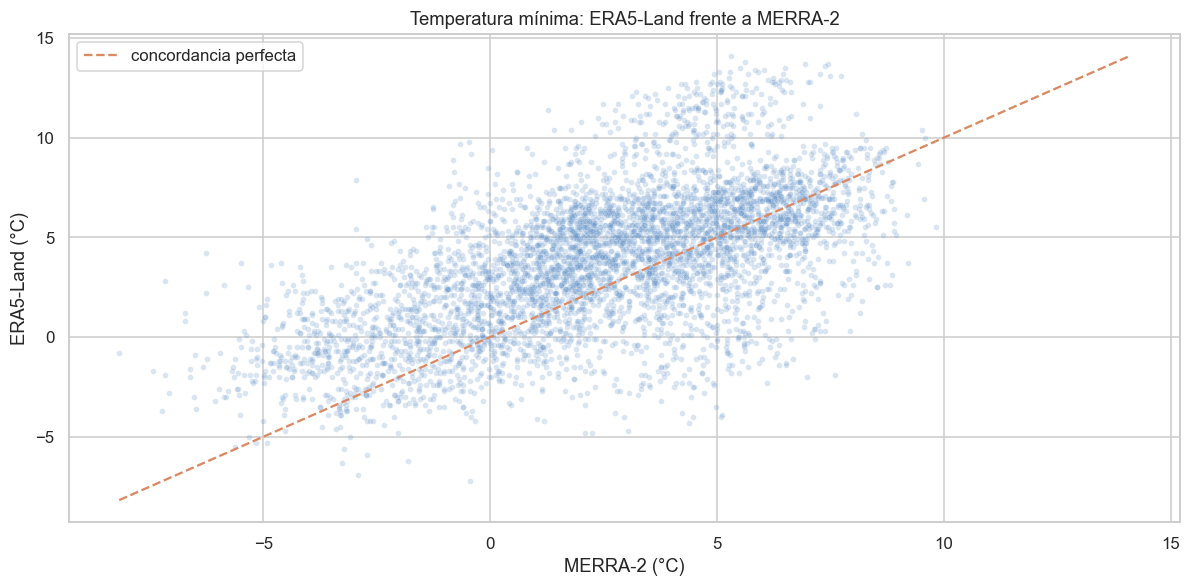

In [12]:
source_validation = compare_sources(clean)
display(pd.Series(source_validation, name='valor').to_frame())
sample_validation = clean.sample(5000, random_state=RANDOM_STATE)
ax = sns.scatterplot(data=sample_validation, x='temperatura_minima_merra2',
                     y='temperatura_minima', alpha=0.22, s=14, color='#578BC5')
limits = [
    min(sample_validation['temperatura_minima_merra2'].min(), sample_validation['temperatura_minima'].min()),
    max(sample_validation['temperatura_minima_merra2'].max(), sample_validation['temperatura_minima'].max()),
]
ax.plot(limits, limits, linestyle='--', color='#DB8963', label='concordancia perfecta')
ax.set(title='Temperatura mínima: ERA5-Land frente a MERRA-2',
       xlabel='MERRA-2 (°C)', ylabel='ERA5-Land (°C)')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretación.** Los 47 489 pares presentan correlación `r = 0,6106`, sesgo medio de `+1,288 °C` para ERA5-Land frente a MERRA-2 y 83,06 % de concordancia binaria. La correlación moderada es coherente con resoluciones y modelos distintos; respalda el patrón general, pero obliga a cautela con valores puntuales.

## 12. Conclusiones, recomendaciones y limitaciones

### Conclusiones

1. El umbral agronómico identifica 39,75 % de observaciones expuestas, frente a 16,05 % con el criterio meteorológico; la elección del umbral cambia materialmente la decisión.
2. El riesgo es territorialmente heterogéneo: Carabaya acumula 1 126 días con helada, mientras Sandia y Yunguyo no registran eventos meteorológicos en sus puntos de malla.
3. La altitud explica parte importante de la mínima media, pero la comparación Yunguyo–San Román demuestra que no basta para zonificar.
4. No existe evidencia de tendencia significativa en el periodo de diez años; no se formula una atribución de cambio climático.
5. Las técnicas multivariantes revelan gradientes continuos más que clases territoriales rígidas; la silueta débil exige prudencia.
6. La validación externa muestra que la señal no depende de un solo producto de reanálisis.

### Recomendaciones

- Priorizar alertas diferenciadas por provincia y por umbral agronómico durante la estación seca.
- Combinar altitud con cercanía al lago, relieve local y observaciones de estación antes de asignar medidas.
- Calibrar el índice de riesgo contra pérdidas de cultivo y ampliar la serie a por lo menos treinta años.
- Mantener visibles los registros marcados y publicar la bitácora de calidad junto con cualquier actualización.

### Limitaciones

La malla de aproximadamente 9 km suaviza extremos locales; los datos son reanálisis y no estaciones; cada provincia se representa por una capital; diez años no constituyen una normal climática; existe un registro de precipitación marcado; la concordancia externa es moderada; no hay rendimientos agrícolas ni daños económicos; y el índice compuesto aún no está calibrado contra daño observado.